In [3]:
# 匯入模組
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

In [41]:
data = pd.read_csv('BackpackPrediction_train.csv')
data.rename('id', 'IDD')

TypeError: DataFrame.rename() takes from 1 to 2 positional arguments but 3 were given

In [3]:
# 刪除類別變項中不含資料的 id
categorical_features = ['Brand', 'Material', 'Size', 'Laptop Compartment', 'Waterproof', 'Style', 'Color']
missing_categorical = data[categorical_features].isnull().any(axis=1)
data = data[~missing_categorical]
data.info() # 再檢查一次是否有缺失值
data = data.drop(columns=['id'])
data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 246686 entries, 0 to 299999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    246686 non-null  int64  
 1   Brand                 246686 non-null  object 
 2   Material              246686 non-null  object 
 3   Size                  246686 non-null  object 
 4   Compartments          246686 non-null  float64
 5   Laptop Compartment    246686 non-null  object 
 6   Waterproof            246686 non-null  object 
 7   Style                 246686 non-null  object 
 8   Color                 246686 non-null  object 
 9   Weight Capacity (kg)  246686 non-null  float64
 10  Price                 246686 non-null  float64
dtypes: float64(3), int64(1), object(7)
memory usage: 22.6+ MB


,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,Jansport,Leather,Medium,7.0,Yes,No,Tote,Black,11.611723,112.15875
1,Jansport,Canvas,Small,10.0,Yes,Yes,Messenger,Green,27.078537,68.88056
2,Under Armour,Leather,Small,2.0,Yes,No,Messenger,Red,16.643760,39.17320
3,Nike,Nylon,Small,8.0,Yes,No,Messenger,Green,12.937220,80.60793
4,Adidas,Canvas,Medium,1.0,Yes,Yes,Messenger,Green,17.749338,86.02312


In [ ]:
# one-hot coding 以及將布林值轉為0/1
data_encoded = pd.get_dummies(data, drop_first=True)
bool_cols = data_encoded.select_dtypes(include=['bool']).columns
data_encoded[bool_cols] = data_encoded[bool_cols].astype(int)

In [14]:
# 標準化數據
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_encoded.drop(columns='Price'))

In [ ]:
# 進行PCA
pca_95 = PCA(n_components=0.95)
X_pca = pca_95.fit_transform(X_scaled)

# 計算變異比例、累積變異比例
explained_variance = pca_95.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

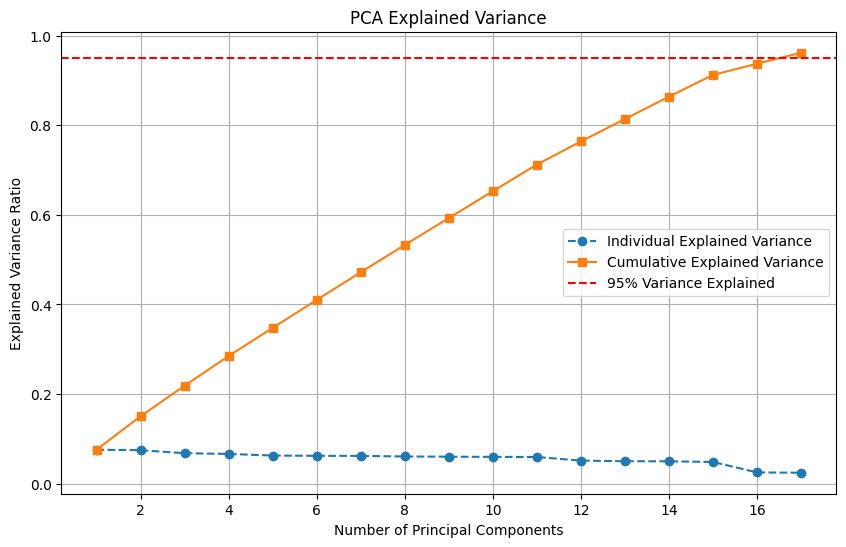

In [33]:
# 視覺化解釋變異比例
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--', label="Individual Explained Variance")
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='s', linestyle='-', label="Cumulative Explained Variance")
plt.axhline(y=0.95, color='r', linestyle='--', label="95% Variance Explained")
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid()
plt.show()

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


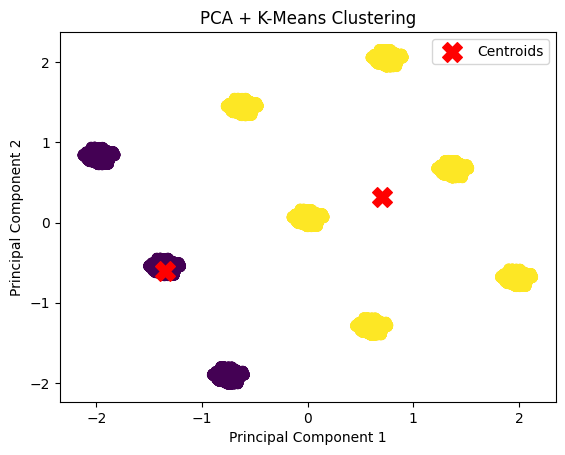

In [35]:
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_pca)

# 5. 視覺化結果
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', marker='X', s=200, label='Centroids')
plt.title("PCA + K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()